In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('creators_expanded.csv')

In [132]:
df['handleName']

0          ongthibalong
1          ongthibalong
2          ongthibalong
3          ongthibalong
4          ongthibalong
              ...      
144213    plak_official
144214    plak_official
144215         lanhgift
144216         lanhgift
144217         lanhgift
Name: handleName, Length: 144218, dtype: object

In [133]:
# Convert time
df['video_createTime'] = pd.to_datetime(df['video_createTime'], unit='s')


In [134]:
df['video_createTime']

0        2026-03-29 14:09:17
1        2026-04-08 14:56:32
2        2026-04-04 15:33:34
3        2026-04-07 14:05:21
4        2026-04-09 12:43:17
                 ...        
144213   2026-03-28 09:22:59
144214   2026-04-04 12:59:51
144215   2026-02-04 05:07:47
144216   2026-02-07 03:24:32
144217   2026-02-07 12:56:26
Name: video_createTime, Length: 144218, dtype: datetime64[ns]

In [135]:

# Crawl time
crawl_time = pd.to_datetime('2026-04-13')


def creator_features(group):
    """
    Input:
        group: DataFrame chứa các video của 1 creator

    Output:
        pd.Series: các đặc trưng ở cấp độ creator
    """
    
    # =========================
    # 1. View stats (đặc trưng quy mô & phân phối)
    # =========================
    # Giá trị nhỏ nhất của view → mức đáy hiệu suất
    min_view = group['video_views'].min()
    
    # Giá trị lớn nhất của view → khả năng viral
    max_view = group['video_views'].max()
    
    # Trung vị → đại diện cho hiệu suất điển hình (robust với outlier)
    median_view = group['video_views'].median()
    
    # Phương sai → đo độ phân tán của view
    var_view = group['video_views'].var()

    # =========================
    # 2. Consistency (độ ổn định)
    # =========================
    # Trung bình view
    mean_view = group['video_views'].mean()
    
    # Độ lệch chuẩn
    std_view = group['video_views'].std()
    
    # Coefficient of Variation (CoV)
    # → đo mức độ biến động tương đối (scale-independent)
    cov_view = std_view / mean_view if mean_view != 0 else np.nan

    # =========================
    # 3. Temporal (hành vi theo thời gian)
    # =========================
    # Sắp xếp thời gian g
    times = group['video_createTime'].sort_values(ascending=True)

    # -------------------------
    # Inter-event time (IET)
    # -------------------------
    # Khoảng cách giữa các lần đăng bài liên tiếp (đơn vị: ngày)
    iet = times.diff().dt.total_seconds().dropna() / 86400
    
    # Trung bình khoảng cách đăng bài
    mean_iet = iet.mean()
    
    # Độ lệch chuẩn của khoảng cách đăng bài
    std_iet = iet.std()

    # -------------------------
    # Burstiness (mức độ đăng dồn dập)
    # -------------------------
    # Công thức:
    # B = ((σ/μ - 1) / (σ/μ + 1))
    # Ý nghĩa:
    #   ~ 0  → đăng đều
    #   > 0  → đăng theo đợt (burst)
    #   < 0  → rất đều (hiếm)
    if mean_iet and mean_iet != 0:
        B = ((std_iet / mean_iet) - 1) / ((std_iet / mean_iet) + 1)
    else:
        B = np.nan

    # -------------------------
    # Total time span
    # -------------------------
    # Khoảng thời gian từ video mới cũ → video mới nhất (đơn vị: ngày)
    total_span = (times.iloc[-1] - times.iloc[0]).total_seconds() / 86400

    # -------------------------
    # Recency (độ "active")
    # -------------------------
    # Khoảng cách từ video mới nhất đến thời điểm crawl
    # → càng nhỏ → creator càng active
    recency = (crawl_time - times.iloc[-1]).total_seconds() / 86400

    # =========================
    # Return kết quả
    # =========================
    return pd.Series({
        # View stats
        'min_view_recent': min_view,
        'max_view_recent': max_view,
        'median_view_recent': median_view,
        'var_view_recent': var_view,
        'mean_view_recent': mean_view,
        'std_view_recent': std_view,
        # Consistency
        'cov_view_recent': cov_view,

        # Temporal
        'mean_iet_days_recent': mean_iet,
        'std_iet_days_recent': std_iet,
        'burstiness_recent': B,
        'total_span_days_recent': total_span,
        'recency_days_recent': recency
    })

In [136]:
df[df['video_createTime'] > crawl_time]

,aioCreatorID,tiktokUID,nickname,handleName,followerCnt,currentScore,currentTier,scoreLowerLimit,scoreUpperLimit,displayType,...,country_JM,country_DO,country_LY,country_IE,country_VI,country_DK,country_BG,country_CH,country_JO,country_IR


In [137]:
print(df['video_createTime'].min())
print(df['video_createTime'].max())
print(crawl_time)

2018-05-30 09:48:16
2026-04-12 23:56:40
2026-04-13 00:00:00


In [138]:
missing_values = ["", " ", "na", "Na", "NA", "null", "Null", "None"]
df = df.replace(missing_values, np.nan)

In [139]:
df['video_createTime']

0        2026-03-29 14:09:17
1        2026-04-08 14:56:32
2        2026-04-04 15:33:34
3        2026-04-07 14:05:21
4        2026-04-09 12:43:17
                 ...        
144213   2026-03-28 09:22:59
144214   2026-04-04 12:59:51
144215   2026-02-04 05:07:47
144216   2026-02-07 03:24:32
144217   2026-02-07 12:56:26
Name: video_createTime, Length: 144218, dtype: datetime64[ns]

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144218 entries, 0 to 144217
Columns: 173 entries, aioCreatorID to country_IR
dtypes: datetime64[ns](1), float64(159), int64(4), object(9)
memory usage: 190.4+ MB


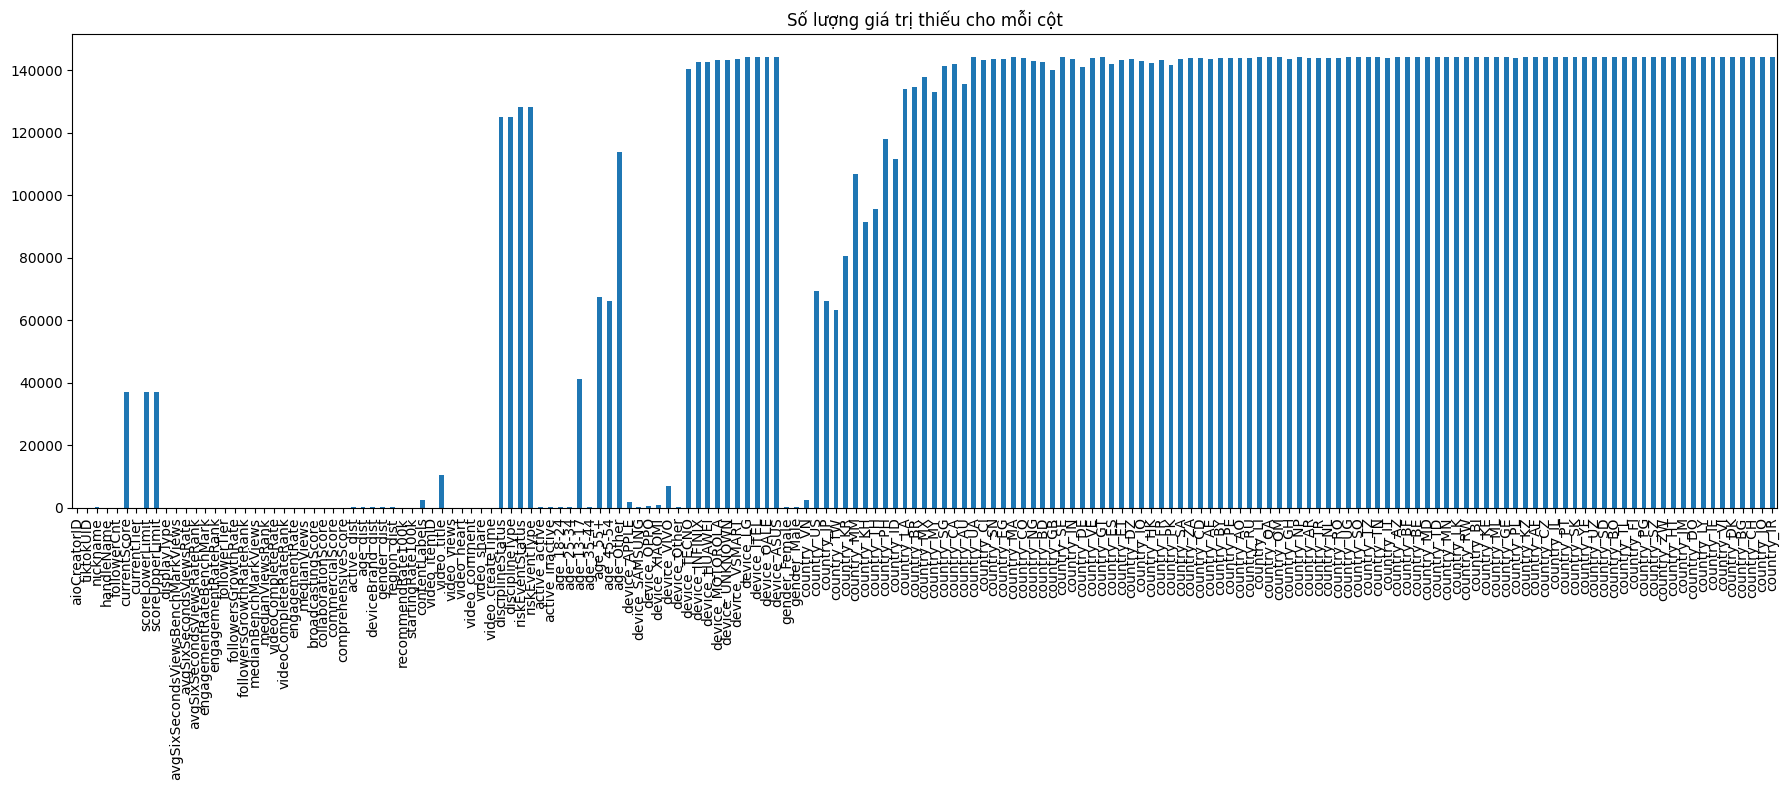

In [141]:
a = df.isna().sum()
plt.figure(figsize=(18, 8))  # 👈 phóng to
a.plot(kind='bar')

plt.title('Số lượng giá trị thiếu cho mỗi cột')
plt.xticks(rotation=90)      # 👈 xoay tên cột
plt.tight_layout()           # 👈 tránh bị cắt chữ

plt.show()

In [145]:
# Apply
creator_df = df.groupby('handleName').apply(creator_features, include_groups=False).reset_index()

## colect feature 

In [146]:
creator_df.head()

,handleName,min_view_recent,max_view_recent,median_view_recent,var_view_recent,mean_view_recent,std_view_recent,cov_view_recent,mean_iet_days_recent,std_iet_days_recent,burstiness_recent,total_span_days_recent,recency_days_recent
0,..nhi1804,25511.0,4082249.0,242310.0,1.271898e+12,727542.400000,1.127784e+06,1.550129,36.716219,35.521879,-0.016533,514.027072,23.389537
1,..vy199x,1007.0,76208.0,2121.0,5.238182e+08,14335.500000,2.288708e+04,1.596531,0.114948,0.133247,0.073726,1.494329,1.415475
2,._.._.73,15847.0,351613.0,68123.0,1.211976e+10,110657.500000,1.100898e+05,0.994870,3.161544,0.940299,-0.541523,41.100069,1.552558
3,._.giirl._xiinh135,1775.0,8535.0,4699.0,5.415533e+06,4765.066667,2.327130e+03,0.488373,0.325511,0.155769,-0.352689,4.557153,1.001030
4,._.illusionlove,14174.0,838967.0,79103.0,5.199611e+10,184105.066667,2.280266e+05,1.238568,4.859069,5.390171,0.051819,68.026968,25.911042


In [147]:
creator_df.columns

Index(['handleName', 'min_view_recent', 'max_view_recent',
       'median_view_recent', 'var_view_recent', 'mean_view_recent',
       'std_view_recent', 'cov_view_recent', 'mean_iet_days_recent',
       'std_iet_days_recent', 'burstiness_recent', 'total_span_days_recent',
       'recency_days_recent'],
      dtype='object')

In [151]:
df.columns

Index(['handleName', 'followerCnt', 'currentScore', 'currentTier',
       'scoreLowerLimit', 'scoreUpperLimit', 'displayType',
       'avgSixSecondsViewsBenchMarkViews', 'avgSixSecondsViewsRate',
       'avgSixSecondsViewsRateRank',
       ...
       'country_JM', 'country_DO', 'country_LY', 'country_IE', 'country_VI',
       'country_DK', 'country_BG', 'country_CH', 'country_JO', 'country_IR'],
      dtype='object', length=158)

In [149]:
df.drop(columns=['aioCreatorID', 'tiktokUID', 'nickname', 'active_dist','age_dist', 'deviceBrand_dist', 'gender_dist', 'region_dist'
                 ,'video_views', 'video_heart', 'video_comment', 'video_share','video_itemID', 'video_title',
                 'video_createTime'
                 ], inplace=True)

In [150]:
df.drop_duplicates(inplace=True)

In [152]:
df = df.merge(creator_df, on='handleName', how='left')


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9918 entries, 0 to 9917
Columns: 170 entries, handleName to recency_days_recent
dtypes: float64(166), int64(2), object(2)
memory usage: 12.9+ MB


In [154]:
df.head()

,handleName,followerCnt,currentScore,currentTier,scoreLowerLimit,scoreUpperLimit,displayType,avgSixSecondsViewsBenchMarkViews,avgSixSecondsViewsRate,avgSixSecondsViewsRateRank,...,median_view_recent,var_view_recent,mean_view_recent,std_view_recent,cov_view_recent,mean_iet_days_recent,std_iet_days_recent,burstiness_recent,total_span_days_recent,recency_days_recent
0,ongthibalong,1063460,70.0,1.0,0.0,100.0,1,0.4604,0.4215,0.6008,...,56334.0,2.088164e+11,1.934880e+05,4.569643e+05,2.361719,1.068552,0.534533,-0.333119,14.959734,3.469942
1,maitrithuc2020,2024865,70.0,1.0,0.0,100.0,1,0.4604,0.4896,0.4250,...,510016.0,1.842786e+12,1.152157e+06,1.357493e+06,1.178219,0.289000,0.324327,0.057600,4.045995,1.400810
2,utthuyss,1287643,NaN,0.0,NaN,NaN,1,0.4604,0.2525,0.8480,...,207247.0,2.950492e+10,2.726299e+05,1.717700e+05,0.630048,0.096873,0.163173,0.254958,1.356215,1.383530
3,nguyen_huynh_tien,3124254,70.0,1.0,0.0,100.0,1,0.4604,0.3096,0.7786,...,38135.0,4.258721e+09,6.821891e+04,6.525888e+04,0.956610,0.235975,0.326395,0.160784,2.359745,1.449954
4,khuyenduong299,1671668,70.0,1.0,0.0,100.0,1,0.4607,0.2484,0.8526,...,552760.0,2.187491e+12,1.321180e+06,1.479017e+06,1.119467,1.432848,1.408185,-0.008681,20.059873,3.432419


In [156]:
df.to_csv('creators_collected.csv', index=False)